In [ ]:
# Company Bankruptcy Prediction

This project aims to predict whether a company is likely to go bankrupt using financial ratios from the Taiwan Economic Journal dataset.

In [1]:
!pip install kaggle -q


In [5]:
import os

os.environ['KAGGLE_API_TOKEN'] = 'KGAT_fe569944eafafcf2b802fb1a5b6d32d0'

In [6]:
!mkdir -p ~/.kaggle
!echo $KAGGLE_API_TOKEN > ~/.kaggle/access_token
!chmod 600 ~/.kaggle/access_token

In [7]:
!kaggle datasets download -d fedesoriano/company-bankruptcy-prediction

Dataset URL: https://www.kaggle.com/datasets/fedesoriano/company-bankruptcy-prediction
License(s): copyright-authors
100% 4.63M/4.63M [00:00<00:00, 97.7MB/s]



In [8]:
!unzip company-bankruptcy-prediction.zip

Archive:  company-bankruptcy-prediction.zip
  inflating: data.csv                


In [9]:
import pandas as pd

df = pd.read_csv("data.csv")
df.head()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


In [10]:
print("Dataset Shape:", df.shape)

print("\nData Types:")
print(df.dtypes.value_counts())

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nTarget Distribution:")
print(df['Bankrupt?'].value_counts())

print("\nTarget Distribution (%):")
print(df['Bankrupt?'].value_counts(normalize=True) * 100)

Dataset Shape: (6819, 96)

Data Types:
float64    93
int64       3
Name: count, dtype: int64

Missing Values:
0

Target Distribution:
Bankrupt?
0    6599
1     220
Name: count, dtype: int64

Target Distribution (%):
Bankrupt?
0    96.77372
1     3.22628
Name: proportion, dtype: float64


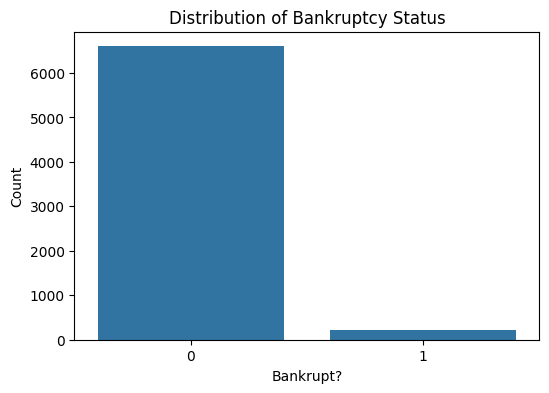

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(
    x='Bankrupt?',
    data=df
)

plt.title('Distribution of Bankruptcy Status')
plt.xlabel('Bankrupt?')
plt.ylabel('Count')

plt.show()

In [12]:
correlation = df.corr()['Bankrupt?'].sort_values()

print("Top 10 Negative Correlations:")
print(correlation.head(10))

print("\nTop 10 Positive Correlations:")
print(correlation.tail(10))

Top 10 Negative Correlations:
Net Income to Total Assets                                -0.315457
ROA(A) before interest and % after tax                    -0.282941
ROA(B) before interest and depreciation after tax         -0.273051
ROA(C) before interest and depreciation before interest   -0.260807
Net worth/Assets                                          -0.250161
Persistent EPS in the Last Four Seasons                   -0.219560
Retained Earnings to Total Assets                         -0.217779
Net profit before tax/Paid-in capital                     -0.207857
Per Share Net profit before tax (Yuan ¥)                  -0.201395
Working Capital to Total Assets                           -0.193083
Name: Bankrupt?, dtype: float64

Top 10 Positive Correlations:
 Liability-Assets Flag                  0.139212
 Current Liabilities/Equity             0.153828
 Current Liability to Equity            0.153828
 Liability to Equity                    0.166812
 Current Liability to Current A

In [ ]:
#Companies exhibiting strong profitability indicators (e.g., ROA and net income ratios) tend to have a lower risk of bankruptcy, whereas
#firms characterized by high leverage and debt dependency demonstrate an increased likelihood of financial distress.

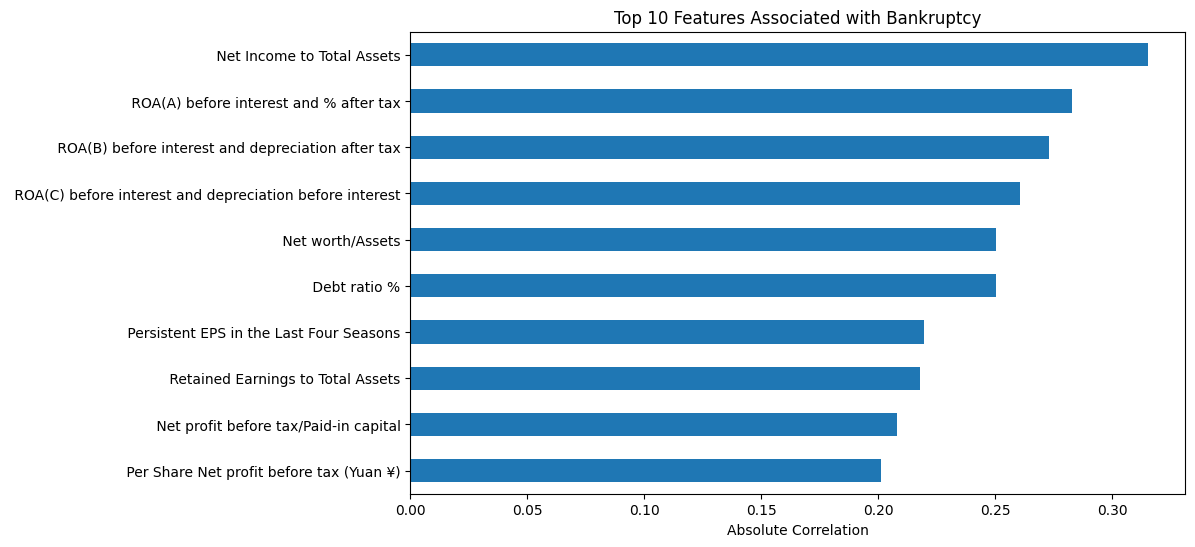

In [14]:
import matplotlib.pyplot as plt

top_features = correlation.drop('Bankrupt?').abs().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_features.sort_values().plot(kind='barh')

plt.title('Top 10 Features Associated with Bankruptcy')
plt.xlabel('Absolute Correlation')

plt.show()

In [15]:
X = df.drop('Bankrupt?', axis=1)
y = df['Bankrupt?']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (6819, 95)
Target Shape: (6819,)


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (5455, 95)
Testing Set: (1364, 95)


In [17]:
print("Original Dataset:")
print(y.value_counts(normalize=True))

print("\nTraining Dataset:")
print(y_train.value_counts(normalize=True))

print("\nTesting Dataset:")
print(y_test.value_counts(normalize=True))

Original Dataset:
Bankrupt?
0    0.967737
1    0.032263
Name: proportion, dtype: float64

Training Dataset:
Bankrupt?
0    0.967736
1    0.032264
Name: proportion, dtype: float64

Testing Dataset:
Bankrupt?
0    0.967742
1    0.032258
Name: proportion, dtype: float64


In [19]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [20]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1320
           1       0.00      0.00      0.00        44

    accuracy                           0.96      1364
   macro avg       0.48      0.50      0.49      1364
weighted avg       0.94      0.96      0.95      1364



In [22]:
from sklearn.linear_model import LogisticRegression

weighted_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

weighted_model.fit(X_train, y_train)

y_pred_weighted = weighted_model.predict(X_test)

In [23]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_weighted
))

              precision    recall  f1-score   support

           0       0.97      0.76      0.85      1320
           1       0.05      0.36      0.09        44

    accuracy                           0.75      1364
   macro avg       0.51      0.56      0.47      1364
weighted avg       0.94      0.75      0.83      1364



In [24]:
!pip install imbalanced-learn -q

In [25]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print(y_train.value_counts())
print()
print(y_train_smote.value_counts())

Bankrupt?
0    5279
1     176
Name: count, dtype: int64

Bankrupt?
0    5279
1    5279
Name: count, dtype: int64


In [26]:
smote_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

smote_model.fit(X_train_smote, y_train_smote)

y_pred_smote = smote_model.predict(X_test)

print(classification_report(y_test, y_pred_smote))

              precision    recall  f1-score   support

           0       0.97      0.77      0.86      1320
           1       0.05      0.34      0.08        44

    accuracy                           0.76      1364
   macro avg       0.51      0.56      0.47      1364
weighted avg       0.94      0.76      0.84      1364



In [27]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [28]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99      1320
           1       0.82      0.20      0.33        44

    accuracy                           0.97      1364
   macro avg       0.90      0.60      0.66      1364
weighted avg       0.97      0.97      0.96      1364



In [29]:
!pip install xgboost -q

In [30]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    scale_pos_weight=30,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

In [31]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1320
           1       0.44      0.55      0.49        44

    accuracy                           0.96      1364
   macro avg       0.71      0.76      0.74      1364
weighted avg       0.97      0.96      0.97      1364



In [33]:
from sklearn.metrics import roc_auc_score

y_prob = xgb.predict_proba(X_test)[:,1]

roc_auc_score(y_test, y_prob)

np.float64(0.9481577134986225)

In [34]:
from sklearn.metrics import roc_auc_score

y_prob = xgb.predict_proba(X_test)[:,1]

roc_auc_score(y_test, y_prob)

np.float64(0.9481577134986225)

<Figure size 1000x800 with 0 Axes>

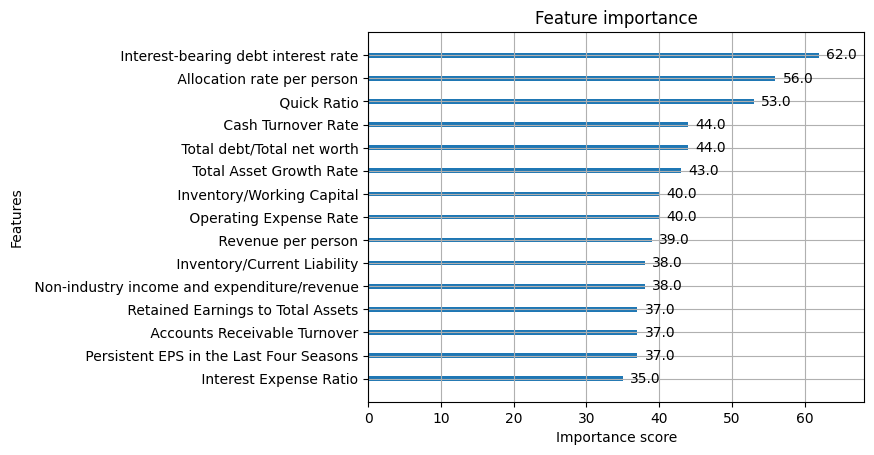

In [35]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plt.figure(figsize=(10,8))
plot_importance(xgb, max_num_features=15)
plt.show()

In [36]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_xgb)
print(cm)

[[1290   30]
 [  20   24]]


In [37]:
!pip install shap -q

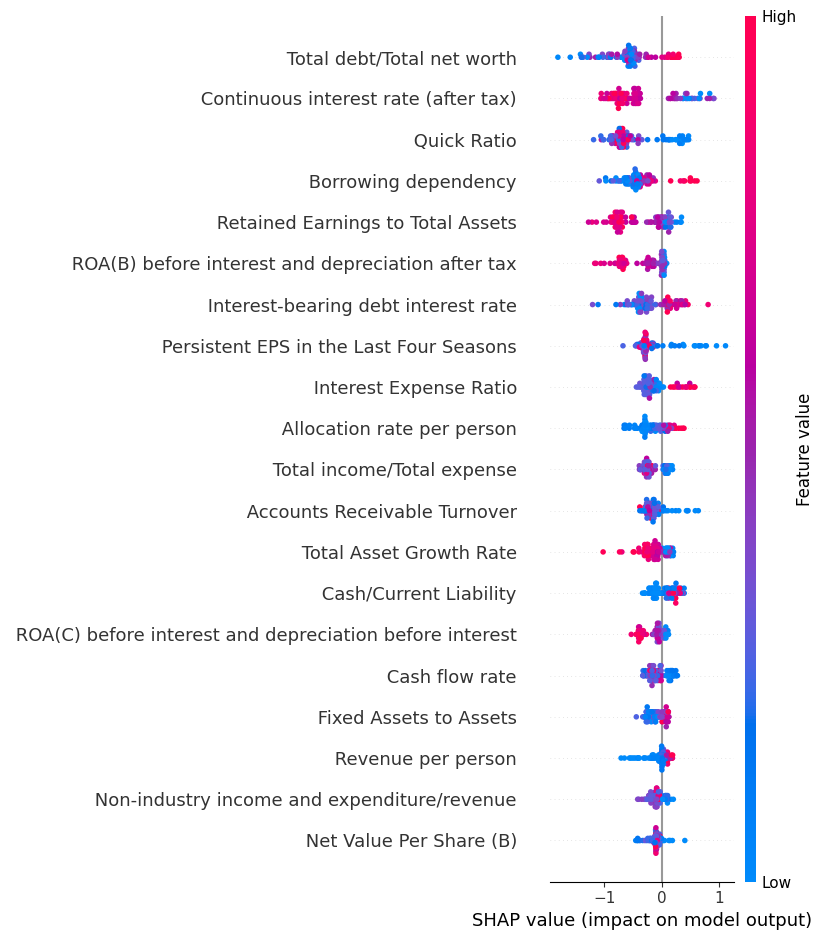

In [38]:
import shap

explainer = shap.TreeExplainer(xgb)

shap_values = explainer.shap_values(X_test.iloc[:100])

shap.summary_plot(
    shap_values,
    X_test.iloc[:100]
)